# Import Libraries

In [1]:
import os
import pickle
import random
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    LabelEncoder,
    OneHotEncoder
)


from sklearn.model_selection import (
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


from sklearn.compose import make_column_selector
from sklearn import set_config
set_config(transform_output="pandas")

from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    PrecisionRecallDisplay
)

from sklearn.utils.class_weight import compute_class_weight

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import json
import os
from PIL import Image

from support_modules.utils import *
from support_modules.plot import *
from support_modules.preprocessing import *
from support_modules.constants import *


# Global Variables

In [2]:
SEED = 42
FILENAME = "../data/train.csv"

WEIGHTS_DIR = "../models"
PREPROCESSOR_DIR = "../preprocessing"
RUNS_DIR = "models"
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(PREPROCESSOR_DIR, exist_ok=True)
os.makedirs(RUNS_DIR, exist_ok=True)

# Cerca la GPU
if torch.backends.mps.is_available():
    print("MPS device is available.")
    device = torch.device("mps")
elif torch.cuda.is_available():
    print("CUDA device is available.")
    device = torch.device("cuda")
else:
    print("No GPU acceleration available.")
    device = torch.device("cpu")

CUDA device is available.


In [3]:
def fix_random(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(SEED)

# Load the dataset

In [4]:
df = pd.read_csv(FILENAME, encoding='ISO-8859-1', sep=",")

rows = df.shape[0]
cols = df.shape[1]
print("# Righe: " + str(rows)+ " # Colonne: "+str(cols) + "\n")

# Righe: 148301 # Colonne: 145



# Preprocessing

## 1. Remove duplicates rows and columns

In [5]:
# Individua se esistono colonne con lo stesso nome
# Se esistono, allora se le colonne sono duplicati perfetti, droppiamo il duplicato
# Se esistono, ma nono sono perfetti duplicati, per intervenire consciamente sarebbe necessario avere maggior domain knowledge
feature_list = df.columns.to_list()
has_duplicate_cols = len(feature_list) != len(set(feature_list))
print("Ci sono colonne con lo stesso nome?", has_duplicate_cols)

if has_duplicate_cols:
    df = df.T.drop_duplicates().T

# Rimuovi righe duplicate
df.drop_duplicates(inplace=True)


rows, cols = df.shape
print("Nuovo # Righe: " + str(rows)+ " Nuovo # Colonne: "+str(cols) + "\n")


Ci sono colonne con lo stesso nome? False
Nuovo # Righe: 148301 Nuovo # Colonne: 145



## 2. Label extraction and train-test splitting

In [6]:
X = df.drop(columns=["grade"])
y = df["grade"]

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

In [8]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)

## 3. Pipeline

In [9]:
remainder_pipeline = Pipeline([
    ('impute_median', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('impute_unknown', SimpleImputer(strategy='constant', fill_value='Unknown'), categorical_to_unknown_cols),
        ('impute_0', SimpleImputer(strategy='constant', fill_value=0), fill_zero_cols),
        ('impute_10k', SimpleImputer(strategy='constant', fill_value=999), fill_big_cols),
        ('impute_mode_cat',SimpleImputer(strategy='most_frequent'), fill_to_mode_cat),
        ('impute_mode_num', SimpleImputer(strategy='most_frequent'), fill_to_mode_num),
    ],
    remainder=remainder_pipeline,
    verbose_feature_names_out=False
)


encoding = ColumnTransformer(
    transformers=[
        ('cat_step', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), make_column_selector(dtype_include=['object'])),
    ], 
    remainder="passthrough", 
    verbose_feature_names_out=False
)

# Feed Forward Neural Network

In [ ]:
class MyDataset(Dataset):
    def __init__(self, X, y):

        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

        self.num_samples = X.shape[0]
        self.num_features = X.shape[1]
        self.num_classes = len(np.unique(y))


    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.X[idx, :], self.y[idx]

In [11]:
@torch.no_grad()
def test_model(model, data_loader, device):
    model.eval()
    preds, trues = [], []
    for data, targets in data_loader:
        preds.append(model(data.to(device)))
        trues.append(targets.to(device))
        
    y_pred = torch.cat(preds)
    y_test = torch.cat(trues)
    
    return y_test, y_pred.argmax(dim=1), y_pred

In [12]:
def train_model(model, criterion, optimizer, num_epochs, scheduler, 
                train_loader, val_loader, device, writer, log_name="best_model", patience=10):
    
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * inputs.size(0)
        
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        model.eval()
        running_val_loss = 0.0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
        
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        
        writer.add_scalar('Loss/train', epoch_train_loss, epoch)
        writer.add_scalar('Loss/val', epoch_val_loss, epoch)
        
        print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}')
        
        # Early stopping sul val loss: salva il best e ferma se non migliora per `patience` epoche.
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), f"models/{log_name}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping all'epoca {epoch+1} (nessun miglioramento del val loss per {patience} epoche).")
                break
        
        #scheduler.step()
        scheduler.step(epoch_val_loss)

        # Prints learning rte
        current_lr = optimizer.param_groups[0]['lr']
        writer.add_scalar('LR', current_lr, epoch)
    
    epochs_ran = len(train_losses)
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, epochs_ran + 1), train_losses, label='Training Loss', marker='o')
    plt.plot(range(1, epochs_ran + 1), val_losses, label='Validation Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    plt.savefig(f'models/{log_name}_loss_plot.png', dpi=300)
    plt.close()
    
    return model

In [13]:
preprocessing_pipeline = Pipeline([
    ('drop_leakage', ColumnDropper(columns=loan_performance_data_leakage + settlement_data_leakage + hardship_data_leakage + other_leakage + loan_contract_interest_rate)),
    ('drop_non_significant', ColumnDropper(columns=other_non_significant)),
    ('drop_high_nan', HighNanDropper(threshold=0.9)),
    ('drop_joint_and_secondary', ColumnDropper(columns=joint_and_secondary_cols)),
    ('high_correlation', HighlyCorrelatedDropper(threshold=0.95)),
    ('feature_extraction', NumericExtractor(columns=number_from_string_cols)),
    ('fico_average', FeatureAverager(columns=average_cols, new_name='fico_average')),
    ('date_diff', DateDifferenceTransformer(reference_col=date_diff_reference, target_cols=date_diff_target)),
    ('rounding_int', RoundToIntTransformer(columns=round_to_nearest_int)),

    ('preprocessor', preprocessor),
    ('encoding', encoding),

    ('scaler', MinMaxScaler())
])

In [14]:
X_train = preprocessing_pipeline.fit_transform(X_train).to_numpy()
X_val = preprocessing_pipeline.transform(X_val).to_numpy()

preprocessor_path = os.path.join(PREPROCESSOR_DIR, "ff_preprocessor.save")
pickle.dump(preprocessing_pipeline, open(preprocessor_path, 'wb'))
print(f"Preprocessor salvato in {preprocessor_path}")

train_subset = MyDataset(X_train,y_train)
val_subset = MyDataset(X_val,y_val)

Preprocessor salvato in ../preprocessing/ff_preprocessor.save


/scratch.hpc/gabriele.aprile2/tmp/ipykernel_2338469/1204839232.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  self.X = torch.FloatTensor(X)


In [15]:
class FeedForward_NN(nn.Module):
    def __init__(self, input_size, num_classes, hidden_size, dropout_rate, depth=1):
        super().__init__()

        def block(in_features, out_features):
            return [
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features),
                nn.ReLU(),
                nn.Dropout(p=dropout_rate),
            ]

        layers = block(input_size, hidden_size)
        for _ in range(depth - 1):
            layers += block(hidden_size, hidden_size)

        self.model = nn.Sequential(*layers)
        self.output = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        return self.output(self.model(x))

In [ ]:
# Con early stopping (vedi train_model) la maggior parte delle run finisce prima di 100 epochs
param_grid = {
    'batch_size':    [512],            # >=256 per stabilita' della BatchNorm
    'hidden_size':   [128, 256, 512],  # 512 opzionale
    'depth':         [1, 2, 3],
    'dropout_rate':  [0.2, 0.4],
    'learning_rate': [3e-4, 1e-3, 3e-3],
    'weight_decay':  [0.0, 1e-4],
}

num_epochs = 100
#gamma = 0.5
#step_size = 10
lr_factor = 0.5          # equivalente a gamma: quanto si riduce il LR
lr_patience = 5          # epoche di stallo prima che lo scheduler riduca il LR
early_stop_patience = 10 # epoche di stallo prima che il training si fermi (invariato, ma ora esplicito e > lr_patience)


# Pesi delle classi per gestire lo sbilanciamento (CrossEntropyLoss pesata).
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_val_acc_overall = 0.0
best_config = None
best_run_name = "" # Inizializza fuori dal ciclo for

for i, config in enumerate(combinations):
    bs = config['batch_size']
    hs = config['hidden_size']
    d = config['depth']
    dr = config['dropout_rate']
    learning_rate = config['learning_rate']
    wd = config['weight_decay']

    print(f"\n[Run {i+1}/{len(combinations)}] Testing: {config}")

    # seed fissato per riproducibilita' ad ogni inizio ciclo
    fix_random(SEED)

    exp_name = f"runs/FFNN_bs{bs}_d{d}_h{hs}_dr{dr}_lr{learning_rate}_wd{wd}"
    writer = SummaryWriter(log_dir=exp_name)

    train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=bs)

    model = FeedForward_NN(train_subset.num_features, train_subset.num_classes, hs, dr, d)
    model.to(device)

    if i == 0:
        data_sample, _ = next(iter(train_loader))
        writer.add_graph(model, data_sample.to(device))

    criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
    #optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=wd)
    #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',        # minimizziamo la val loss
    factor=lr_factor,         # stesso fattore di riduzione che avevi con gamma
    patience=lr_patience,          # epoche di tolleranza PRIMA di ridurre il LR
    threshold=1e-4,      # miglioramento minimo per considerarlo "reale"
    min_lr=1e-6          # limite inferiore, evita LR che va a zero
)

    # Nome univoco per il miglior modello di QUESTA specifica run
    current_run_model_name = f"best_model_run_{i}"

    model = train_model(model, criterion, optimizer, num_epochs, scheduler,
                        train_loader, val_loader, device, writer, log_name=current_run_model_name,  patience=early_stop_patience)

    model.load_state_dict(torch.load(f"models/{current_run_model_name}", weights_only=True))
    model.to(device)

    labels_val, preds_val, _ = test_model(model, val_loader, device)

    y_true = labels_val.cpu().numpy()
    y_pred = preds_val.cpu().numpy()

    acc = (preds_val == labels_val).float().mean().item()
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    f1_weighted = f1_score(y_true, y_pred, average='weighted') # Media pesata tra le classi

    print(f"--- Risultati Run {i+1} ---")
    print(f"Accuracy Standard: {acc:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"F1 Score (weighted):  {f1_weighted:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Aggiungiamo tutte le metriche per poterle confrontare nella tabella Hparams di TensorBoard
    writer.add_hparams(
        config,
        {
            "hparam/accuracy": acc,
            "hparam/balanced_accuracy": balanced_acc,
            "hparam/f1_weighted": f1_weighted
        }
    )


    if balanced_acc > best_val_acc_overall:
        best_val_acc_overall = balanced_acc
        best_config = config
        best_run_name = exp_name
        best_run_index = i
        torch.save(model.state_dict(), os.path.join(WEIGHTS_DIR, "ff.pth"))
        
        ff_metadata = {
            'input_size': train_subset.num_features,
            'num_classes': train_subset.num_classes,
            'hidden_size': hs,
            'dropout_rate': dr,
            'depth': d
        }

        pickle.dump(ff_metadata, open(os.path.join(WEIGHTS_DIR, "ff_metadata.save"), 'wb'))
        print(f"Nuovo miglior modello trovato nella run: {best_run_name} !!!")

        best_model_summary = {
            "model_name": "FeedForward_NN",
            "best_config": best_config,
            "metrics": {
                "best_balanced_accuracy": best_val_acc_overall,
            },
            "tensorboard_log_dir": best_run_name,
            "architecture_preview": str(model)
        }

    writer.flush()
    writer.close()

print("\n" + "="*40)
print(f"GRID SEARCH TERMINATA")
print(f"Miglior accuratezza: {best_val_acc_overall:.4f}")
print(f"Miglior configurazione: {best_config}")


[Run 1/108] Testing: {'batch_size': 512, 'hidden_size': 128, 'depth': 1, 'dropout_rate': 0.2, 'learning_rate': 0.0003, 'weight_decay': 0.0}
Epoch 1/100 - Train Loss: 1.7144, Val Loss: 1.5383
Epoch 2/100 - Train Loss: 1.5114, Val Loss: 1.4660
Epoch 3/100 - Train Loss: 1.4653, Val Loss: 1.4408
Epoch 4/100 - Train Loss: 1.4409, Val Loss: 1.4246
Epoch 5/100 - Train Loss: 1.4275, Val Loss: 1.4152
Epoch 6/100 - Train Loss: 1.4157, Val Loss: 1.4101
Epoch 7/100 - Train Loss: 1.4082, Val Loss: 1.4049
Epoch 8/100 - Train Loss: 1.4016, Val Loss: 1.4030
Epoch 9/100 - Train Loss: 1.3967, Val Loss: 1.3992
Epoch 10/100 - Train Loss: 1.3924, Val Loss: 1.3961
Epoch 11/100 - Train Loss: 1.3865, Val Loss: 1.3945
Epoch 12/100 - Train Loss: 1.3816, Val Loss: 1.3932
Epoch 13/100 - Train Loss: 1.3793, Val Loss: 1.3946
Epoch 14/100 - Train Loss: 1.3763, Val Loss: 1.3910
Epoch 15/100 - Train Loss: 1.3716, Val Loss: 1.3897
Epoch 16/100 - Train Loss: 1.3705, Val Loss: 1.3881
Epoch 17/100 - Train Loss: 1.3658, V

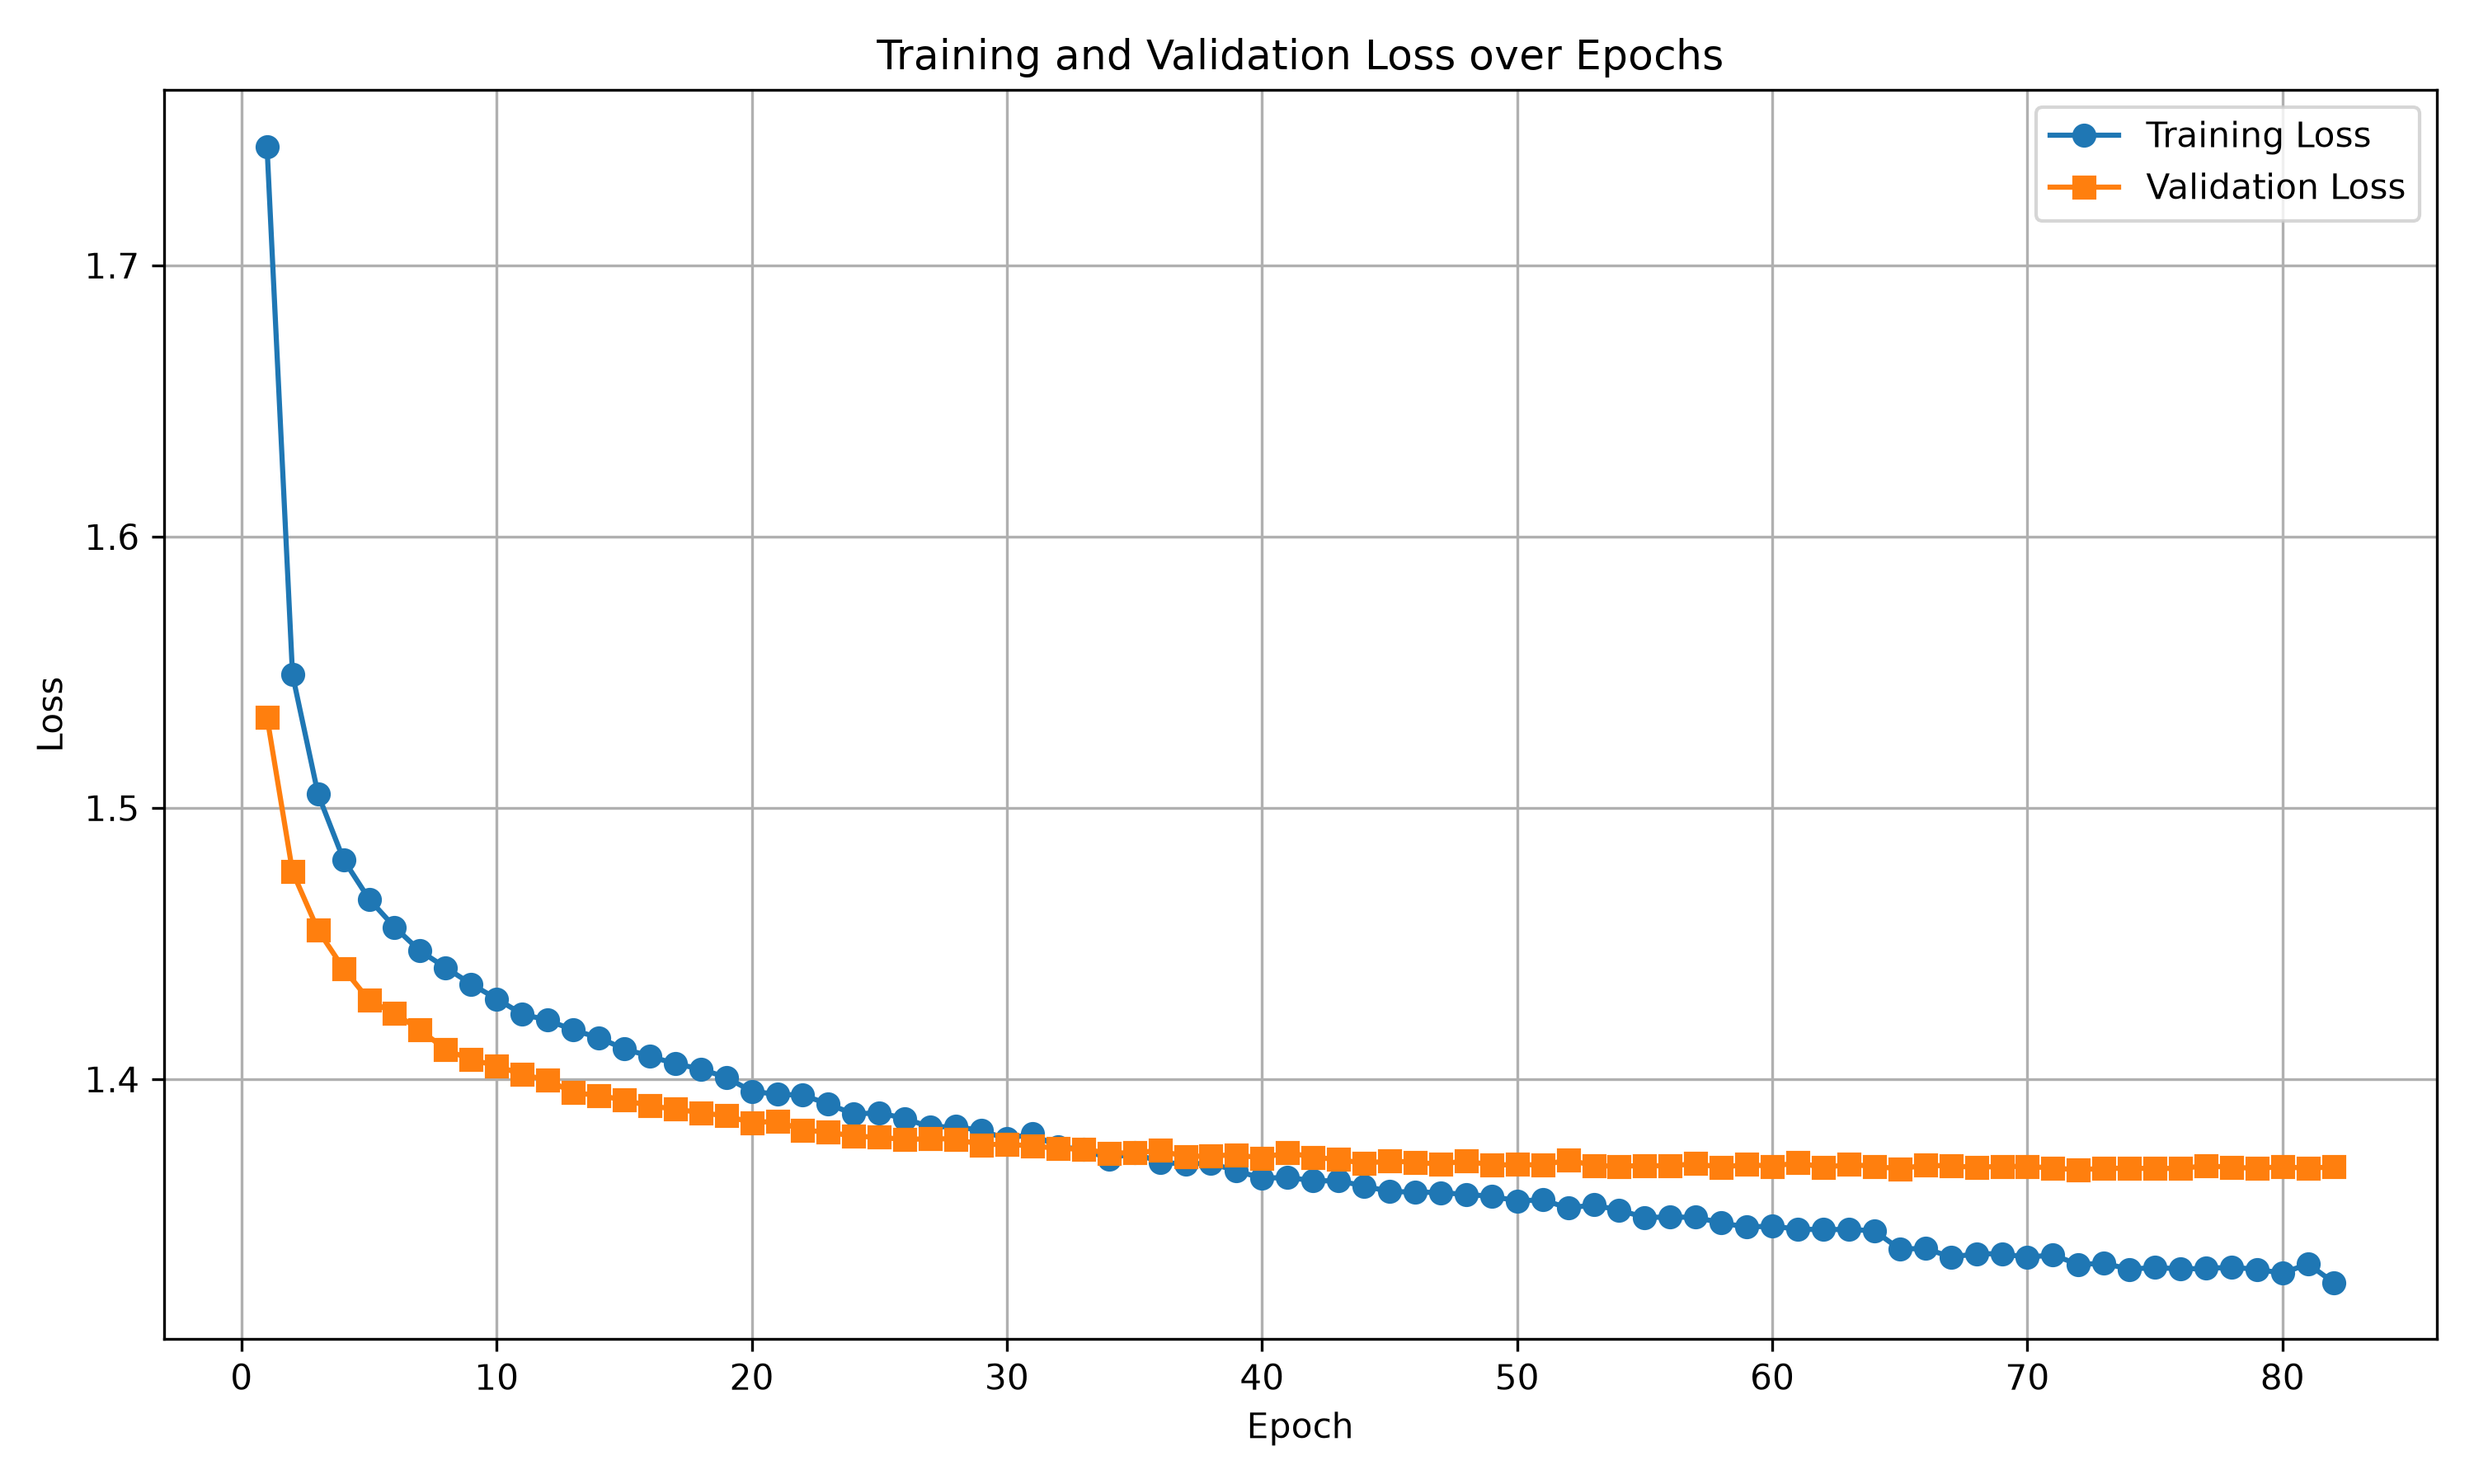

In [25]:
img = Image.open(f"models/best_model_run_{best_run_index}_loss_plot.png")
img  # o plt.imshow(img) / display(img)

In [26]:

json_path = os.path.join(WEIGHTS_DIR, "ff_best.json")
with open(json_path, "w") as f:
    json.dump(best_model_summary, f, indent=4)

print("\n" + "="*40)
print("SALVATAGGIO COMPLETATO")
print(f"Pesi salvati in: {os.path.join(WEIGHTS_DIR, 'ff.pth')}")
print(f"Metadati salvati in: {os.path.join(WEIGHTS_DIR, 'ff_metadata.save')}")
print(f"Info e run salvate in: {json_path}")
print(f"Per vedere i grafici, cerca su TensorBoard: {best_run_name}")
print("="*40)


SALVATAGGIO COMPLETATO
Pesi salvati in: ../models/ff.pth
Metadati salvati in: ../models/ff_metadata.save
Info e run salvate in: ../models/ff_best.json
Per vedere i grafici, cerca su TensorBoard: runs/FFNN_bs512_d2_h128_dr0.4_lr0.0003_wd0.0


In [27]:
json_path = os.path.join(WEIGHTS_DIR, "ff_best.json")

with open(json_path, "r") as f:
    best_model_summary = json.load(f)

print("="*50)
print("BEST MODEL SUMMARY")
print("="*50)
print(f"Model name:            {best_model_summary['model_name']}")
print(f"Best config:")
for k, v in best_model_summary['best_config'].items():
    print(f"    {k:15s}: {v}")
print(f"\nBest balanced accuracy: {best_model_summary['metrics']['best_balanced_accuracy']:.4f}")
print(f"TensorBoard log dir:    {best_model_summary['tensorboard_log_dir']}")
print("\nArchitecture preview:")
print(best_model_summary['architecture_preview'])
print("="*50)

BEST MODEL SUMMARY
Model name:            FeedForward_NN
Best config:
    batch_size     : 512
    hidden_size    : 128
    depth          : 2
    dropout_rate   : 0.4
    learning_rate  : 0.0003
    weight_decay   : 0.0

Best balanced accuracy: 0.4174
TensorBoard log dir:    runs/FFNN_bs512_d2_h128_dr0.4_lr0.0003_wd0.0

Architecture preview:
FeedForward_NN(
  (model): Sequential(
    (0): Linear(in_features=154, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
  )
  (output): Linear(in_features=128, out_features=7, bias=True)
)


In [28]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(best_run_name)
ea.Reload()

val_loss_events = ea.Scalars('Loss/val')
losses = [(e.step, e.value) for e in val_loss_events]

best_epoch, best_loss = min(losses, key=lambda x: x[1])
print(f"Il best model è stato salvato all'epoca {best_epoch + 1} (val loss = {best_loss:.4f})")

Il best model è stato salvato all'epoca 72 (val loss = 1.3666)


BEST MODEL — validation set
Accuracy Standard:    0.4214
Balanced Accuracy:    0.4174
F1 Score (weighted):  0.4140

Classification Report:
              precision    recall  f1-score   support

           A       0.62      0.79      0.70      6634
           B       0.49      0.44      0.46      9435
           C       0.44      0.32      0.37      9270
           D       0.29      0.18      0.22      5314
           E       0.21      0.26      0.23      3021
           F       0.22      0.34      0.27      1881
           G       0.25      0.59      0.35      1521

    accuracy                           0.42     37076
   macro avg       0.36      0.42      0.37     37076
weighted avg       0.43      0.42      0.41     37076



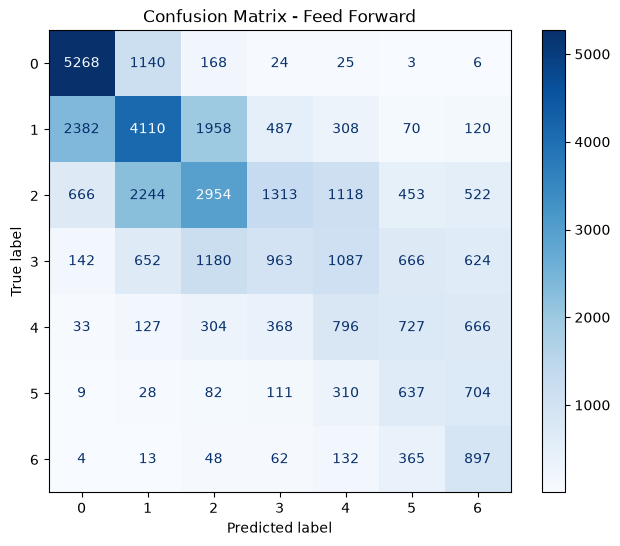

In [46]:
ff_metadata = pickle.load(open(os.path.join(WEIGHTS_DIR, "ff_metadata.save"), "rb"))

best_model = FeedForward_NN(
    input_size=ff_metadata['input_size'],
    num_classes=ff_metadata['num_classes'],
    hidden_size=ff_metadata['hidden_size'],
    dropout_rate=ff_metadata['dropout_rate'],
    depth=ff_metadata['depth'],
)
best_model.load_state_dict(torch.load(os.path.join(WEIGHTS_DIR, "ff.pth"), weights_only=True))
best_model.to(device)

val_loader = DataLoader(val_subset, batch_size=1024)
labels_val, preds_val, _ = test_model(best_model, val_loader, device)

y_true = labels_val.cpu().numpy()
y_pred = preds_val.cpu().numpy()

class_names = [str(c) for c in le.classes_]

acc          = (y_pred == y_true).mean()
balanced_acc = balanced_accuracy_score(y_true, y_pred)
f1_weighted  = f1_score(y_true, y_pred, average='weighted')

print("=" * 60)
print("BEST MODEL — validation set")
print("=" * 60)
print(f"Accuracy Standard:    {acc:.4f}")
print(f"Balanced Accuracy:    {balanced_acc:.4f}")
print(f"F1 Score (weighted):  {f1_weighted:.4f}")


print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Feed Forward')
plt.show()